In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/canarywharf_r10_2025-03_04.csv")


df['ts'] = pd.to_datetime(df['ts'], unit='s')

print("Total records:", len(df))
print("Unique users:", df['id'].nunique())

Total records: 4547198
Unique users: 456567


In [18]:
df['hour'] = df['ts'].dt.hour
df['category'] = df['id'].apply(classify)

In [2]:
# Keep only stop points
df = df[df['type'] == 'stop'].copy()

print("After stop filter:", len(df))
print("Unique users after stop filter:", df['id'].nunique())

After stop filter: 1876684
Unique users after stop filter: 157101


In [8]:
df_test = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/likely_workers_ids.csv")

print(df_test.columns)
print(df_test.head())

Index(['user_id'], dtype='object')
                            user_id
0  0004149d28cf68bafa4235d888bf148f
1  000c29b9516def0bec8cf107234ee1f1
2  00145899d6aaa6a4a203a5bb332ddbfb
3  001e5b171a43a454fbe96d4d826a9e04
4  0022aaa1e46e3b4bae313f35af842a92


In [10]:
df_test = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/leisure_user_ids.csv")

print(df_test.columns)
print(df_test.head())

Index(['id'], dtype='object')
                                 id
0  72acce929c19b80498f8b4ff3404bdf5
1  af85c9573e94fda59a2dc00e39d2385f
2  fb3a01d8715ccc97cbeacfac7d246f78
3  0f2f4e3b5e95ac52945028d8bc5760ca
4  b569b4cd71ba948a7516fc56d5aab8fd


In [11]:
df_test = pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/cw_residents_user_ids.csv")

print(df_test.columns)
print(df_test.head())

Index(['id'], dtype='object')
                                 id
0  89d35ecab631eaf0cc9a78ca76432af7
1  14a3f503d1badc1dbeeb9c30120db4e3
2  1eebadfc992998c793bf90c651aaadff
3  d1c4fb566d6033449556131c1f5beeb5
4  de556a685de8053e469a645c2de428d3


In [12]:
# Load ID lists

resident_ids = set(pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/cw_residents_user_ids.csv")['id'])

worker_ids = set(pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/likely_workers_ids.csv")['user_id'])

leisure_ids = set(pd.read_csv("/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/leisure_user_ids.csv")['id'])

print("Residents:", len(resident_ids))
print("Workers:", len(worker_ids))
print("Leisure:", len(leisure_ids))

Residents: 11903
Workers: 9962
Leisure: 45547


In [13]:
print("Residents ∩ Workers:", len(resident_ids & worker_ids))
print("Residents ∩ Leisure:", len(resident_ids & leisure_ids))
print("Workers ∩ Leisure:", len(worker_ids & leisure_ids))

Residents ∩ Workers: 4516
Residents ∩ Leisure: 0
Workers ∩ Leisure: 74


In [16]:
#CATEGORY COLUMN

def classify(uid):
    if uid in resident_ids:
        return "resident"
    elif uid in worker_ids:
        return "worker"
    elif uid in leisure_ids:
        return "leisure"
    else:
        return "other"

df['category'] = df['id'].apply(classify)

print(df['category'].value_counts())

category
resident    891605
other       546229
leisure     288006
worker      150844
Name: count, dtype: int64


# temporal pattern

In [19]:
# -----------------------------
# HOURLY DISTRIBUTION
# -----------------------------
hourly = (
    df.groupby(['category', 'hour'])
    .size()
    .reset_index(name='count')
)

In [20]:
print(df[['ts', 'hour', 'category']].head())

                    ts  hour  category
0  2025-03-31 00:46:41     0     other
3  2025-03-25 03:29:04     3     other
5  2025-03-30 11:26:06    11   leisure
8  2025-03-27 05:29:51     5  resident
13 2025-03-31 10:43:22    10    worker


In [21]:
# -----------------------------
# HOURLY DISTRIBUTION
# -----------------------------
hourly = (
    df.groupby(['category', 'hour'])
    .size()
    .reset_index(name='count')
)

# Normalize
hourly['normalized'] = hourly.groupby('category')['count'].transform(
    lambda x: x / x.sum()
)

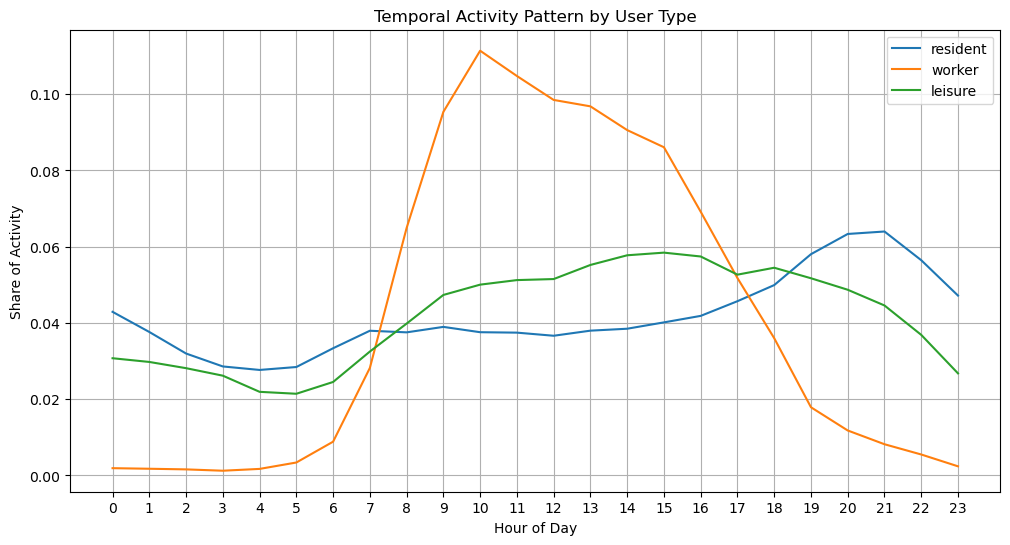

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for cat in ['resident', 'worker', 'leisure']:
    subset = hourly[hourly['category'] == cat]
    if not subset.empty:
        plt.plot(subset['hour'], subset['normalized'], label=cat)


plt.xlabel("Hour of Day")
plt.ylabel("Share of Activity")
plt.title("Temporal Activity Pattern by User Type")
plt.legend()
plt.grid(True)
plt.xticks(range(0,24))

plt.show()